In [1]:
import numpy as np
import matplotlib.pyplot as plt
import RF_Track

# Beam parameters
mass = RF_Track.electronmass    # MeV/c^2
population = 300 * RF_Track.pC  # pC → RF_Track units
Q = -1
P_ref = 198                     # MeV/c

# Lattice parameters
Ldrift = 1.0       # m
Lquad  = 0.226     # m

def get_ITF(I):
    return 1.29404711e-2  - 2.59458259e-07*I  # T/A

def get_grad(I, Lquad):
    return I * get_ITF(I) / Lquad             # T/m

def get_Quad_K(G_0, P_ref):
    return 299.8 * G_0 / P_ref                # 1/m^2

def get_Quad_K_from_I(I, Lquad, P_ref):
    G_0 = get_grad(I, Lquad)
    return get_Quad_K(G_0, P_ref)

def get_lattice(Iquad):
    G0 = get_grad(Iquad, Lquad)
    K1 = get_Quad_K(G0, P_ref)

    Quad = RF_Track.Quadrupole(Lquad, P_ref/Q, K1)
    Dr   = RF_Track.Drift(Ldrift)
    Dr.set_tt_nsteps(100)
    Scr  = RF_Track.Screen()

    L = RF_Track.Lattice()
    L.append(Quad)
    L.append(Dr)
    L.append(Scr)
    print("Lattice length =", L.get_length(), "m")
    return L

# --- Twiss at quad entrance ---
Twiss = RF_Track.Bunch6d_twiss()
Twiss.beta_x  = 15.6
Twiss.beta_y  = 24.0
Twiss.alpha_x = -0.49
Twiss.alpha_y = -3.65
Twiss.emitt_x = 7.04  # mm mrad (normalised)
Twiss.emitt_y = 3.39

N = 10000
B0 = RF_Track.Bunch6d(mass, population, Q, P_ref, Twiss, N)



RF-Track, version 2.5.4

Copyright (C) 2016-2025 CERN, Geneva, Switzerland. All rights reserved.

Author and contact:
 Andrea Latina <andrea.latina@cern.ch>
 BE-ABP Group
 CERN
 CH-1211 GENEVA 23
 SWITZERLAND

This software is distributed under a CERN proprietary software
license in the hope that it will be useful, but WITHOUT ANY WARRANTY;
not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

See the COPYRIGHT and LICENSE files at the top-level directory of
the RF-Track download area: https://gitlab.cern.ch/rf-track

RF-Track was compiled with GSL-2.8 and fftw-3.3.10



[RF-Track] Could not check for updates.


In [2]:
def get_Twiss(Bunch):
    I0 = Bunch.get_info()
    return I0  # we can just return the full info object

def print_Twiss(Bunch, label=""):
    I0 = Bunch.get_info()
    if label:
        print(f"\n--- {label} ---")
    print(f"s          : {I0.S:.3f} m")
    print(f"beta_x     : {I0.beta_x:.3f} m")
    print(f"beta_y     : {I0.beta_y:.3f} m")
    print(f"alpha_x    : {I0.alpha_x:.3f}")
    print(f"alpha_y    : {I0.alpha_y:.3f}")
    print(f"emit_x,n   : {I0.emitt_x:.3f} mm·mrad")
    print(f"emit_y,n   : {I0.emitt_y:.3f} mm·mrad")
    print(f"sigma_x    : {I0.sigma_x:.3f} mm")
    print(f"sigma_y    : {I0.sigma_y:.3f} mm")


Lattice length = 1.226 m

--- Initial ---
s          : 0.000 m
beta_x     : 15.360 m
beta_y     : 23.949 m
alpha_x    : -0.480
alpha_y    : -3.639
emit_x,n   : 7.040 mm·mrad
emit_y,n   : 3.390 mm·mrad
sigma_x    : 0.528 mm
sigma_y    : 0.458 mm

--- Final at screen ---
s          : 1.226 m
beta_x     : 5.749 m
beta_y     : 64.144 m
alpha_x    : 3.246
alpha_y    : -21.846
emit_x,n   : 7.040 mm·mrad
emit_y,n   : 3.390 mm·mrad
sigma_x    : 0.323 mm
sigma_y    : 0.749 mm


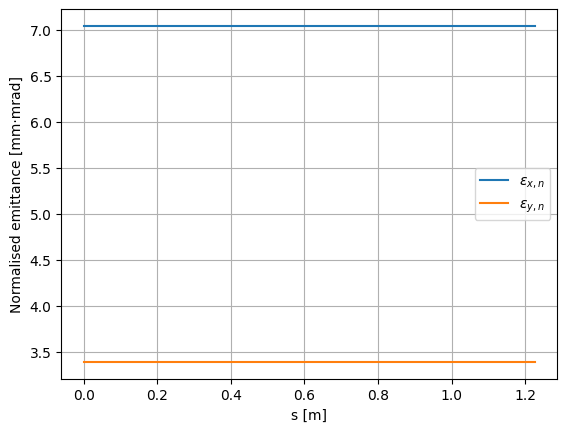

In [3]:
Iquad = 20.0  # A

L = get_lattice(Iquad)
B1 = L.track(B0)

print_Twiss(B0, "Initial")
print_Twiss(B1, "Final at screen")

# Emittance evolution along the line
T = L.get_transport_table('%S %emitt_x %emitt_y')

plt.figure()
plt.plot(T[:,0], T[:,1], label=r'$\epsilon_{x,n}$')
plt.plot(T[:,0], T[:,2], label=r'$\epsilon_{y,n}$')
plt.xlabel('s [m]')
plt.ylabel('Normalised emittance [mm·mrad]')
plt.legend()
plt.grid(True)
plt.show()


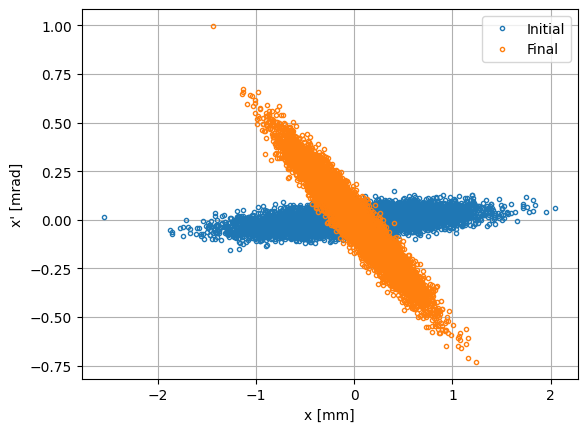

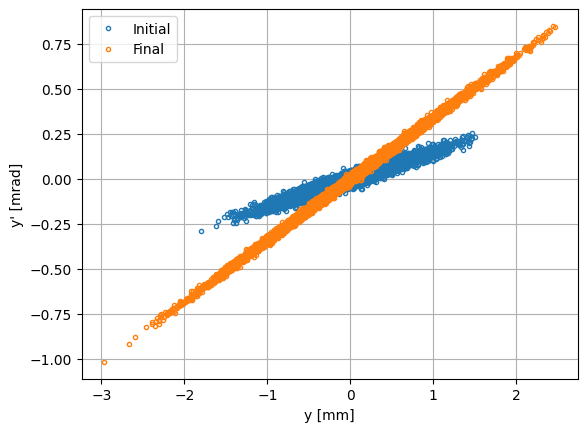

In [4]:
M0 = B0.get_phase_space('%x %xp %y %yp %dt %P')
M1 = B1.get_phase_space('%x %xp %y %yp %dt %P')

plt.figure()
plt.plot(M0[:,0], M0[:,1], '.', label='Initial', mfc='none')
plt.plot(M1[:,0], M1[:,1], '.', label='Final',   mfc='none')
plt.xlabel('x [mm]')
plt.ylabel("x' [mrad]")
plt.legend()
plt.grid(True)

plt.figure()
plt.plot(M0[:,2], M0[:,3], '.', label='Initial', mfc='none')
plt.plot(M1[:,2], M1[:,3], '.', label='Final',   mfc='none')
plt.xlabel('y [mm]')
plt.ylabel("y' [mrad]")
plt.legend()
plt.grid(True)
plt.show()


Lattice length = 1.226 m
Lattice length = 1.226 m
Lattice length = 1.226 m
Lattice length = 1.226 m
Lattice length = 1.226 m
Lattice length = 1.226 m
Lattice length = 1.226 m
Lattice length = 1.226 m
Lattice length = 1.226 m
Lattice length = 1.226 m
Lattice length = 1.226 m


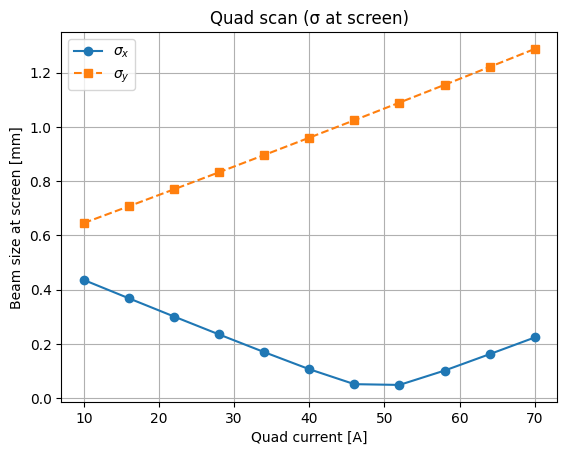

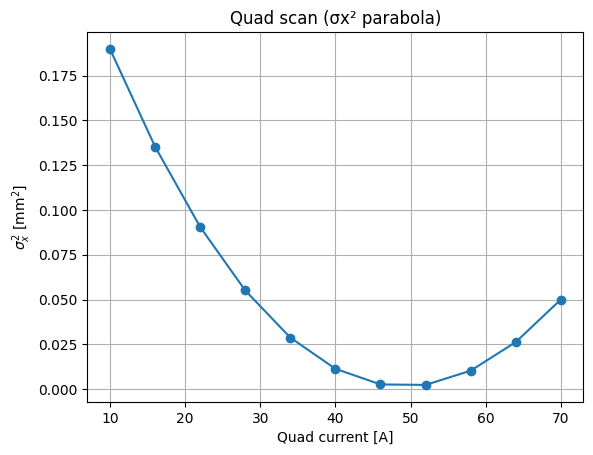

In [5]:
currents = np.linspace(10, 70, 11)
sigma_x = []
sigma_y = []

for I in currents:
    L = get_lattice(I)
    B = L.track(B0)
    # beam sizes along the line
    T = L.get_transport_table('%S %sigma_x %sigma_y')
    sigma_x.append(T[-1,1])  # σx at screen
    sigma_y.append(T[-1,2])  # σy at screen

sigma_x = np.array(sigma_x)
sigma_y = np.array(sigma_y)

plt.figure()
plt.plot(currents, sigma_x, 'o-', label=r'$\sigma_x$')
plt.plot(currents, sigma_y, 's--', label=r'$\sigma_y$')
plt.xlabel('Quad current [A]')
plt.ylabel('Beam size at screen [mm]')
plt.title('Quad scan (σ at screen)')
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(currents, sigma_x**2, 'o-')
plt.xlabel('Quad current [A]')
plt.ylabel(r'$\sigma_x^2$ [mm$^2$]')
plt.title('Quad scan (σx²)')
plt.grid(True)
plt.show()


In [6]:
def R_matrix_linear(B0, B1):
    """
    Fit only K (offset) + linear 6x6 R matrix:
        X1 ≈ K + R · X0
    using many particles.
    """
    M0 = B0.get_phase_space('%x %xp %y %yp %dt %pt')
    M1 = B1.get_phase_space('%x %xp %y %yp %dt %pt')

    x0, xp0, y0, yp0, t0, d0 = M0.T
    x1, xp1, y1, yp1, t1, d1 = M1.T

    I  = np.ones_like(x0)
    I0 = np.vstack([I, x0, xp0, y0, yp0, t0, d0]).T   # (N, 7)
    I1 = np.vstack([x1, xp1, y1, yp1, t1, d1]).T      # (N, 6)

    M = np.linalg.lstsq(I0, I1, rcond=None)[0].T      # (6, 7)
    K = M[:,0]
    R = M[:,1:7]
    return K, R


In [7]:
Iquad = 20.0
L = get_lattice(Iquad)
B1 = L.track(B0)

K, R = R_matrix_linear(B0, B1)
print("R-matrix (linear):")
print(R)


Lattice length = 1.226 m
R-matrix (linear):
[[ 5.70098780e-01  1.17874175e+00  1.27920687e-15 -7.02479669e-15
   0.00000000e+00  0.00000000e+00]
 [-3.85962797e-01  9.56061576e-01  3.25680734e-16 -3.07546201e-16
   0.00000000e+00  0.00000000e+00]
 [-1.45347462e-16 -8.36420640e-15  1.44211374e+00  1.27394087e+00
   0.00000000e+00  0.00000000e+00]
 [-1.10259579e-16  2.81480396e-16  3.97522213e-01  1.04459153e+00
   0.00000000e+00  0.00000000e+00]
 [-1.76269451e-07  6.62710291e-06 -3.17702448e-07 -1.25000277e-05
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]
